In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint, uniform, loguniform

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, 
    cross_validate, StratifiedKFold, KFold
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import Ridge, LinearRegression, LogisticRegression
from sklearn.svm import SVC, SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    make_scorer, mean_squared_error, mean_absolute_error, r2_score,
    roc_auc_score, precision_score, recall_score, f1_score,
    precision_recall_curve
)

In [2]:

df = pd.read_csv('/kaggle/input/forest-fire-area/forestfires.csv')

# esta es la cara del dataset
df.head()


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


Zeros: 247 (47.78%)
Non-zeros: 270 (52.22%)


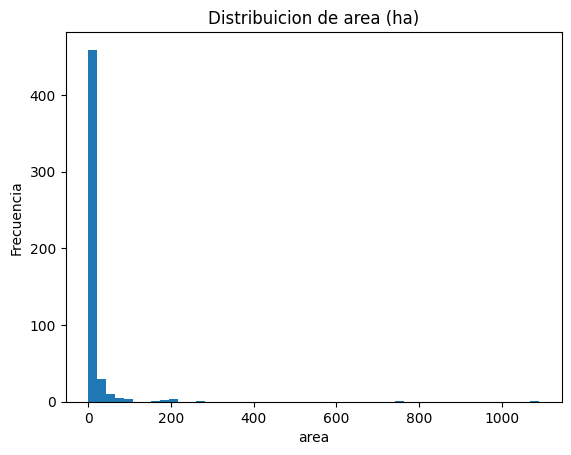

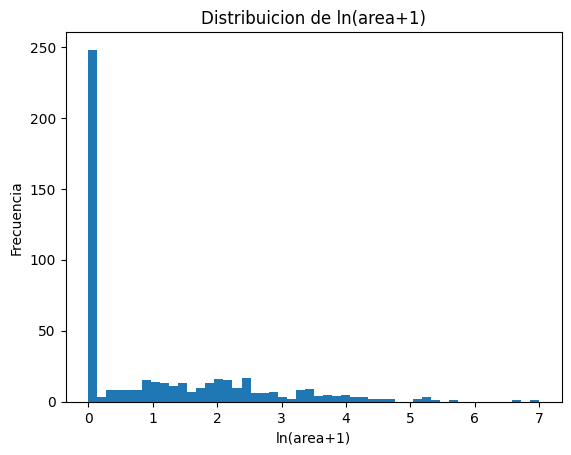

In [3]:

# chequeando alineas zeros y non-zeros 
total = len(df)
zeros = (df['area'] == 0).sum()
nonzeros = total - zeros
print(f'Zeros: {zeros} ({zeros/total:.2%})')
print(f'Non-zeros: {nonzeros} ({nonzeros/total:.2%})')

# histograma de area (ha)
plt.figure()
plt.hist(df['area'], bins=50)
plt.title('Distribuicion de area (ha)')
plt.xlabel('area')
plt.ylabel('Frecuencia')
plt.show()

# log-transform e histograma de ln(area+1) con la misma dimension de bins=50
df['log_area'] = np.log1p(df['area'])
plt.figure()
plt.hist(df['log_area'], bins=50)
plt.title('Distribuicion de ln(area+1)')
plt.xlabel('ln(area+1)')
plt.ylabel('Frecuencia')
plt.show()


#se verifica que con la transformacion de ln(area+1) se visualiza mejor los datos de la extencion de los incendios en comparacion con las ocurrencias de zero ha


              FFMC       DMC        DC       ISI      temp        RH  \
FFMC      1.000000  0.382619  0.330512  0.531805  0.431532 -0.300995   
DMC       0.382619  1.000000  0.682192  0.305128  0.469594  0.073795   
DC        0.330512  0.682192  1.000000  0.229154  0.496208 -0.039192   
ISI       0.531805  0.305128  0.229154  1.000000  0.394287 -0.132517   
temp      0.431532  0.469594  0.496208  0.394287  1.000000 -0.527390   
RH       -0.300995  0.073795 -0.039192 -0.132517 -0.527390  1.000000   
wind     -0.028485 -0.105342 -0.203466  0.106826 -0.227116  0.069410   
rain      0.056702  0.074790  0.035861  0.067668  0.069491  0.099751   
log_area  0.046799  0.067153  0.066360 -0.010347  0.053487 -0.053662   

              wind      rain  log_area  
FFMC     -0.028485  0.056702  0.046799  
DMC      -0.105342  0.074790  0.067153  
DC       -0.203466  0.035861  0.066360  
ISI       0.106826  0.067668 -0.010347  
temp     -0.227116  0.069491  0.053487  
RH        0.069410  0.099751 -0.0

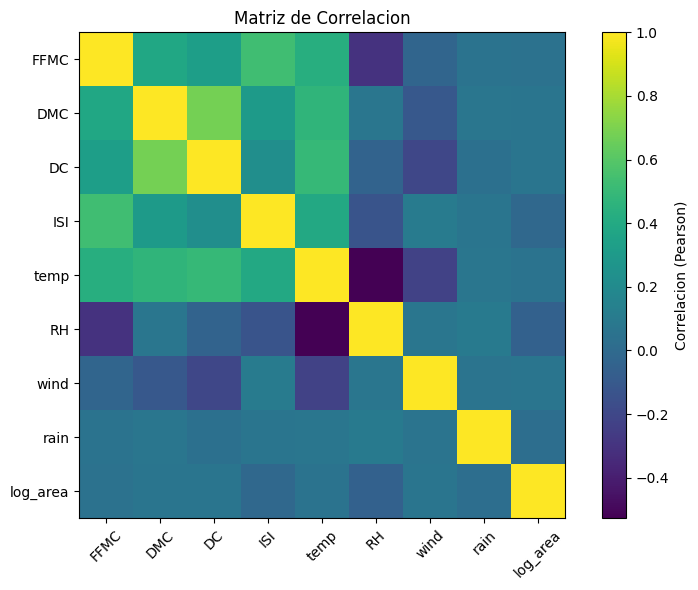

In [4]:
#verificando la correlacion entre los variables numericos candidatos a features para el modelo y su relacion con el target


#columnas que queremos vaarificar (variables numericos)
cols = ['FFMC','DMC','DC','ISI','temp','RH','wind','rain','log_area']
corr = df[cols].corr()

# matriz de correlacion
print(corr)

# heatmap para visualizar la correlacion
plt.figure(figsize=(8,6))
plt.imshow(corr, interpolation='none')
plt.colorbar(label='Correlacion (Pearson)')
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)
plt.title('Matriz de Correlacion')
plt.tight_layout()
plt.show()

#La matriz de correlacion nos confirma que 1) No han pares con multicolinearidad preocupante y 2) todas las variables numericas tienen una correlacion directa bastante baja con el target
# 3) quizas utilizar clasificacion de los casos de incendio antes de aplicar la regresion (double phase pipeline) para captar las interacciones no lineares mejore los resultados


In [5]:
#Entrenamiento sencillo de un SVR con pre-pocesamiento y transformacion de escalas

X = df.drop(columns=['area', 'log_area'])
y = df['log_area']

# train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4)  tipos de feature
numeric_features  = ['X','Y','FFMC','DMC','DC','ISI','temp','RH','wind','rain']
categorical_feats = ['month','day']
meses = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
dias  = ['mon','tue','wed','thu','fri','sat','sun']

# 5) Pre-processing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(
        categories=[meses, dias],
        drop='first',
        sparse_output=False,
        handle_unknown='ignore'
    ), categorical_feats)
])


# 3. Pipeline : SVR
svr = Pipeline([
    ('pre', preprocessor),
    ('svr', SVR(kernel='rbf', C=1.0, epsilon=0.1))
])

# entrenando svr
svr.fit(X_train, y_train)

y_pred_log = svr.predict(X_test)

# reverte para escala real
y_test_real = np.expm1(y_test)       
y_pred_real = np.expm1(y_pred_log)

# 7. Calcula MAE e RMSE na escala real
mae_real  = mean_absolute_error(y_test_real, y_pred_real)
rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f"MAE (área):  {mae_real:.4f}")
print(f"RMSE (área): {rmse_real:.4f}")


MAE (área):  19.5686
RMSE (área): 110.1368


In [6]:


#Empezamos a ver como se sale un modelo de regresion lineal

# df = df[df['area'] > 0].copy()
#X = df.drop(columns=['area', 'log_area'])
#y = df['log_area']


# 6) Pipelines
pipe_ridge = Pipeline([
    ('pre',   preprocessor),
    ('model', Ridge(alpha=1.0, random_state=42))
])

pipe_pca_lr = Pipeline([
    ('pre',   preprocessor),
    ('pca',   PCA(n_components=0.90, random_state=42)),
    ('model', LinearRegression())
])

# 7) Scorers en escala real  (estas son las metricas y el cv que vamos utilizar)
scoring = {
    'RMSE': make_scorer(
        lambda y_true, y_pred: np.sqrt(
            mean_squared_error(np.expm1(y_true), np.expm1(y_pred))
        ),
        greater_is_better=False
    ),
    'MAE': make_scorer(
        lambda y_true, y_pred: mean_absolute_error(
            np.expm1(y_true), np.expm1(y_pred)
        ),
        greater_is_better=False
    ),
    'R2': make_scorer(r2_score)  
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 8) Cross-validate
scores_ridge  = cross_validate(pipe_ridge,  X, y, scoring=scoring, cv=cv)
scores_pca_lr = cross_validate(pipe_pca_lr, X, y, scoring=scoring, cv=cv)

# 9) Agrupa resultados
results = pd.DataFrame({
    'Model': ['Ridge', 'PCA + LinearRegression'],
    'RMSE':  [-scores_ridge['test_RMSE'].mean(),  -scores_pca_lr['test_RMSE'].mean()],
    'MAE':   [-scores_ridge['test_MAE'].mean(),   -scores_pca_lr['test_MAE'].mean()],
    'R2':     [ scores_ridge['test_R2'].mean(),   scores_pca_lr['test_R2'].mean()]
})

print(results)

#tambien fue testeado y si sacamos los datos area=0, el resultado se queda peor

                    Model       RMSE        MAE        R2
0                   Ridge  54.546251  12.937309 -0.065600
1  PCA + LinearRegression  54.616788  12.995452 -0.064276


In [7]:


# 1) Cargar datos e crear target binário
df = pd.read_csv('/kaggle/input/forest-fire-area/forestfires.csv')
df['fire'] = (df['area'] > 0).astype(int)


X = df.drop(columns=['area', 'fire'])
y = df['fire']

# 3) Definir features
numeric_features   = ['X','Y','FFMC','DMC','DC','ISI','temp','RH','wind','rain']
categorical_feats  = ['month','day']

# 4) Preprocessor (já configurado)
meses = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
dias  = ['mon','tue','wed','thu','fri','sat','sun']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(
        categories=[meses, dias],
        drop='first',
        sparse_output=False,
        handle_unknown='ignore'
    ), categorical_feats)
])

# 5) Pipeline SVC
pipe_svc = Pipeline([
    ('pre', preprocessor),
    ('clf', SVC(kernel='rbf', probability=True, random_state=42))
])

# 6) GridSearchCV para SVC
param_grid_svc = {
    'clf__C':     [0.1, 1, 10],
    'clf__gamma': ['scale', 'auto', 0.1, 1, 10]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_svc = GridSearchCV(
    estimator=pipe_svc,
    param_grid=param_grid_svc,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
gs_svc.fit(X, y)

print("SVC Best ROC-AUC: {:.4f}".format(gs_svc.best_score_))
print("SVC Best Params:", gs_svc.best_params_)

# 7) Avaliar o melhor SVC em outras métricas
best_svc = gs_svc.best_estimator_
scoring = {
    'ROC_AUC': make_scorer(roc_auc_score, needs_proba=True),
    'Precision': make_scorer(precision_score),
    'Recall': make_scorer(recall_score),
    'F1': make_scorer(f1_score)
}
scores_svc = cross_validate(best_svc, X, y, scoring=scoring, cv=cv, return_train_score=False)

results_svc = pd.DataFrame({
    'Metric': ['ROC_AUC','Precision','Recall','F1'],
    'Mean Score': [
        np.mean(scores_svc['test_ROC_AUC']),
        np.mean(scores_svc['test_Precision']),
        np.mean(scores_svc['test_Recall']),
        np.mean(scores_svc['test_F1'])
    ]
})
print("\nPerformance do Melhor SVC:")
print(results_svc)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
SVC Best ROC-AUC: 0.5799
SVC Best Params: {'clf__C': 1, 'clf__gamma': 10}

Performance do Melhor SVC:
      Metric  Mean Score
0    ROC_AUC    0.581377
1  Precision    0.529017
2     Recall    0.981481
3         F1    0.687448


In [8]:


# 1. Carrega e prepara os dados (supondo que você já fez o que mostrou)
data = pd.read_csv('/kaggle/input/forest-fire-area/forestfires.csv')
data['area_log'] = np.log1p(data['area'])
y = data['area_log']
X = data.drop(['area', 'area_log'], axis=1)
X = pd.get_dummies(X, columns=['month', 'day'], drop_first=True).astype(float)

# 2. Divide em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Monte um pipeline com normalização + SVR
pipeline = Pipeline([
    ('scaler', StandardScaler()),             # padroniza variáveis
    ('svr', SVR(kernel='rbf',                  # SVM com kernel RBF
                 C=1.0,                        # penalidade
                 epsilon=0.1))                 # tubo de insensibilidade
])

# 4. Treina o modelo
pipeline.fit(X_train, y_train)

# 5. Faz predições
y_pred = pipeline.predict(X_test)

# 6. Calcula MAE e RMSE
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE:  1.1661
RMSE: 1.6384


In [9]:

# 1) Carregar e preparar dados
df = pd.read_csv('/kaggle/input/forest-fire-area/forestfires.csv')
df['fire'] = (df['area'] > 0).astype(int)
X = df.drop(columns=['area','fire'])
y = df['fire']

# 2) Pré-processamento (mesmo de antes)
numeric_features  = ['X','Y','FFMC','DMC','DC','ISI','temp','RH','wind','rain']
categorical_feats = ['month','day']
meses = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
dias  = ['mon','tue','wed','thu','fri','sat','sun']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(
                categories=[meses, dias],
                drop='first',
                sparse_output=False,
                handle_unknown='ignore'
           ), categorical_feats)
])

# 3) Modelo SVC otimizado + calibração
svc = SVC(kernel='rbf', C=1, gamma=10, probability=True, random_state=42)
pipe = Pipeline([
    ('pre', preprocessor),
    ('svc', svc)
])
# Calibração interna 5-fold
calib = CalibratedClassifierCV(pipe, cv=5, method='sigmoid')
calib.fit(X, y)

# 4) Probabilidades calibradas
probs = calib.predict_proba(X)[:,1]

# 5) Busca de threshold para maximizar F1
best_thr, best_f1 = 0.5, 0
metrics = []
for thr in np.linspace(0.01, 0.99, 99):
    preds = (probs >= thr).astype(int)
    f1 = f1_score(y, preds)
    metrics.append((thr, f1))
    if f1 > best_f1:
        best_f1, best_thr = f1, thr

# 6) Métricas no melhor threshold
preds = (probs >= best_thr).astype(int)
prec = precision_score(y, preds)
rec  = recall_score(y, preds)

print(f"Melhor threshold = {best_thr:.2f} → F1 = {best_f1:.3f}")
print(f"Precision @thr: {prec:.3f}")
print(f"Recall    @thr: {rec:.3f}")


Melhor threshold = 0.01 → F1 = 0.686
Precision @thr: 0.522
Recall    @thr: 1.000


In [10]:



# 1) Carregar e preparar dados
df = pd.read_csv('/kaggle/input/forest-fire-area/forestfires.csv')
df['fire'] = (df['area'] > 0).astype(int)
X = df.drop(columns=['area','fire'])
y = df['fire']

# 2) Pré-processamento (mesmo de antes)
numeric_features  = ['X','Y','FFMC','DMC','DC','ISI','temp','RH','wind','rain']
categorical_feats = ['month','day']
meses = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
dias  = ['mon','tue','wed','thu','fri','sat','sun']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(
                categories=[meses, dias],
                drop='first',
                sparse_output=False,
                handle_unknown='ignore'
           ), categorical_feats)
])



svc_bal = SVC(
    kernel='rbf',
    C=1,
    gamma=10,
    probability=True,
    class_weight='balanced',
    random_state=42
)

# 2) Monte o pipeline com seu preprocessor
pipe_bal = Pipeline([
    ('pre', preprocessor),
    ('svc', svc_bal)
])

# 3) Calibre o classificador (Platt scaling)
calib_bal = CalibratedClassifierCV(pipe_bal, cv=5, method='sigmoid')
calib_bal.fit(X, y)

# 4) Gere as probabilidades calibradas
probs_bal = calib_bal.predict_proba(X)[:, 1]

# 5) Varra thresholds para maximizar F1
best_thr, best_f1 = 0.5, 0
for thr in np.linspace(0.01, 0.99, 99):
    preds = (probs_bal >= thr).astype(int)
    f1 = f1_score(y, preds)
    if f1 > best_f1:
        best_f1, best_thr = f1, thr

# 6) Calcule Precision e Recall no best threshold
preds_bal = (probs_bal >= best_thr).astype(int)
prec_bal = precision_score(y, preds_bal)
rec_bal  = recall_score(y, preds_bal)

# 7) Mostre os resultados
print(f"SVC balanced + calibração → Melhor threshold = {best_thr:.2f}")
print(f"F1        = {best_f1:.3f}")
print(f"Precision = {prec_bal:.3f}")
print(f"Recall    = {rec_bal:.3f}")

SVC balanced + calibração → Melhor threshold = 0.01
F1        = 0.686
Precision = 0.522
Recall    = 1.000


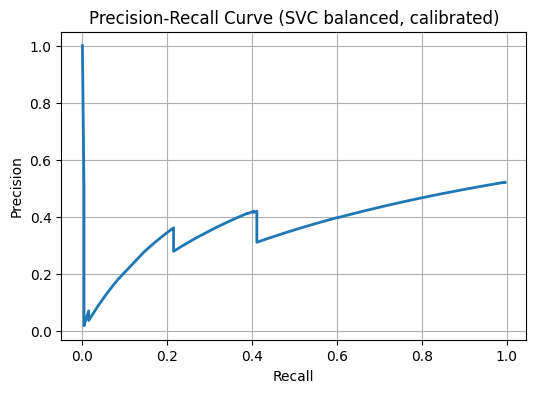

Threshold optimo p/ F1: 0.353 → F1 = 0.685
Threshold p/ Recall ≥ 0.8: 0.381 → Precision = 0.468, Recall = 0.800


In [11]:

# 1) Carregar e preparar dados
df = pd.read_csv('/kaggle/input/forest-fire-area/forestfires.csv')
df['fire'] = (df['area'] > 0).astype(int)
X = df.drop(columns=['area','fire'])
y = df['fire']

# 2) Pré-processamento (mesmo de antes)
numeric_features  = ['X','Y','FFMC','DMC','DC','ISI','temp','RH','wind','rain']
categorical_feats = ['month','day']
meses = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
dias  = ['mon','tue','wed','thu','fri','sat','sun']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(
                categories=[meses, dias],
                drop='first',
                sparse_output=False,
                handle_unknown='ignore'
           ), categorical_feats)
])

svc_bal = SVC(kernel='rbf', C=1, gamma=10, probability=True,
              class_weight='balanced', random_state=42)
pipe_bal = Pipeline([
    ('pre', preprocessor),
    ('svc', svc_bal)
])

# 2) Calibrar probabilidades (Platt scaling)
calib_bal = CalibratedClassifierCV(pipe_bal, cv=5, method='sigmoid')
calib_bal.fit(X, y)

# 3) Obter probabilidades calibradas
probs = calib_bal.predict_proba(X)[:, 1]

# 4) Calcular precision, recall e thresholds
precision, recall, thresholds = precision_recall_curve(y, probs)

# 5) Alinhar thresholds (thresholds[i] corresponde a precision[i+1], recall[i+1])
pr = precision[1:]
rc = recall[1:]
th = thresholds

# 6) Encontrar threshold que maximiza F1
f1_scores = 2 * pr * rc / (pr + rc + 1e-8)
best_idx = np.nanargmax(f1_scores)
best_thr = th[best_idx]
best_f1 = f1_scores[best_idx]

# 7) Threshold para recall ≥ 0.8
mask = rc >= 0.8
if mask.any():
    thr_rec08 = th[mask][-1]
    prec_rec08 = pr[mask][-1]
    rec_rec08  = rc[mask][-1]
else:
    thr_rec08 = None

# 8) Plot da Curva Precision-Recall
plt.figure(figsize=(6,4))
plt.plot(rc, pr, linewidth=2)
plt.title('Precision-Recall Curve (SVC balanced, calibrated)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

# 9) Exibir resultados
print(f"Threshold optimo p/ F1: {best_thr:.3f} → F1 = {best_f1:.3f}")
if thr_rec08 is not None:
    print(f"Threshold p/ Recall ≥ 0.8: {thr_rec08:.3f} → Precision = {prec_rec08:.3f}, Recall = {rec_rec08:.3f}")





Global:
    fire       pct
0     1  0.522244
1     0  0.477756 

Treino:
    fire       pct
0     1  0.523002
1     0  0.476998 

Teste:
    fire       pct
0     1  0.519231
1     0  0.480769
Classificação (threshold=0.381):
 Precision: 0.519
 Recall:    1.000
 F1-score:  0.684
 Support incêndios reais: 54, previstos: 104

 Regressão de área:
 RMSE: 37.265 ha
 MAE:  14.210 ha


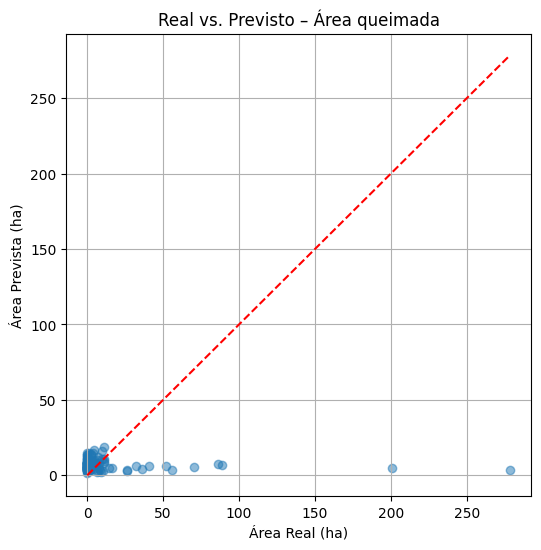

In [12]:



df = pd.read_csv('/kaggle/input/forest-fire-area/forestfires.csv')
df['fire']     = (df['area'] > 0).astype(int)
df['log_area'] = np.log1p(df['area'])

X = df.drop(columns=['area','log_area','fire'])
y_fire = df['fire']
y_log  = df['log_area']

# ———————————————————————————
#split stratified
X_train, X_test, yf_train, yf_test, yl_train, yl_test = train_test_split(
    X, y_fire, y_log,
    test_size=0.2,
    stratify=y_fire,
    random_state=42
)

dist_global = (
    pd.concat([yf_train, yf_test])
      .value_counts(normalize=True)
      .rename_axis('fire')
      .reset_index(name='pct')
)
dist_train  = yf_train.value_counts(normalize=True).rename_axis('fire').reset_index(name='pct')
dist_test   = yf_test.value_counts(normalize=True).rename_axis('fire').reset_index(name='pct')

print("Global:\n", dist_global, "\n")
print("Treino:\n", dist_train, "\n")
print("Teste:\n", dist_test)

# ———————————————————————————

numeric_features  = ['X','Y','FFMC','DMC','DC','ISI','temp','RH','wind','rain']
categorical_feats = ['month','day']
meses = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
dias  = ['mon','tue','wed','thu','fri','sat','sun']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(
        categories=[meses, dias],
        drop='first',
        sparse_output=False,
        handle_unknown='ignore'
    ), categorical_feats)
])

# ———————————————————————————
# 4) Clasificación SVC balanced + calibracion 
svc = SVC(kernel='rbf', C=1, gamma=10,
          probability=True,
          class_weight='balanced',
          random_state=42)

clf_pipe = Pipeline([
    ('pre', preprocessor),
    ('svc', svc)
])
calibrated_clf = CalibratedClassifierCV(clf_pipe, cv=5, method='sigmoid')
calibrated_clf.fit(X_train, yf_train)

# Prever no teste com threshold=0.381 (passo 4.1)
probs_test  = calibrated_clf.predict_proba(X_test)[:,1]
threshold   = 0.381
yf_pred     = (probs_test >= threshold).astype(int)

# Métricas de classificação
prec = precision_score(yf_test, yf_pred)
rec  = recall_score(yf_test, yf_pred)
f1   = f1_score(yf_test, yf_pred)

print("Classificação (threshold=0.381):")
print(f" Precision: {prec:.3f}")
print(f" Recall:    {rec:.3f}")
print(f" F1-score:  {f1:.3f}")
print(f" Support incêndios reais: {yf_test.sum()}, previstos: {yf_pred.sum()}")

# ———————————————————————————
# 5) Regressão: SVR em log_area (passo 3B)
svr = SVR(kernel='rbf', C=1, gamma='scale')
reg_pipe = Pipeline([
    ('pre', preprocessor),
    ('svr', svr)
])
# Treinar só onde houve incêndio no treino
mask_train = yf_train == 1
reg_pipe.fit(X_train[mask_train], yl_train[mask_train])

# Prever no teste apenas nos positivos
yl_pred = np.zeros_like(yl_test)
mask_test = yf_pred == 1
yl_pred[mask_test] = reg_pipe.predict(X_test[mask_test])

# Converter de volta a hectares
area_true = np.expm1(yl_test)
area_pred = np.expm1(yl_pred)

# Métricas de regressão (passo 4.2)
rmse = np.sqrt(mean_squared_error(area_true, area_pred))
mae  = mean_absolute_error(area_true, area_pred)

print('\n Regressão de área:')
print(f" RMSE: {rmse:.3f} ha")
print(f" MAE:  {mae:.3f} ha")

# ———————————————————————————
# Opcional: scatter real vs. previsto (passo 4.3)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(area_true, area_pred, alpha=0.5)
lims = [0, max(area_true.max(), area_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Área Real (ha)')
plt.ylabel('Área Prevista (ha)')
plt.title('Real vs. Previsto – Área queimada')
plt.grid(True)
plt.show()


In [13]:
#SVR OTIMIZADO


# 1) Carregar dados e fazer o split 80/20 estratificado em 'fire'
df = pd.read_csv('/kaggle/input/forest-fire-area/forestfires.csv') 
df['fire']     = (df['area'] > 0).astype(int)
df['log_area'] = np.log1p(df['area'])

X       = df.drop(columns=['area','log_area','fire'])
y_fire  = df['fire']
y_log   = df['log_area']

X_train, X_test, yf_train, yf_test, yl_train, yl_test = train_test_split(
    X, y_fire, y_log,
    test_size=0.2,
    stratify=y_fire,
    random_state=42
)

# 2) Preprocessor (igual ao utilizado antes)
numeric_features  = ['X','Y','FFMC','DMC','DC','ISI','temp','RH','wind','rain']
categorical_feats = ['month','day']
meses = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
dias  = ['mon','tue','wed','thu','fri','sat','sun']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(
        categories=[meses, dias],
        drop='first',
        sparse_output=False,
        handle_unknown='ignore'
    ), categorical_feats)
])

# 3) Filtrar o treino para casos com incêndio
mask_train    = yf_train == 1
X_reg_train   = X_train[mask_train]
y_reg_train   = yl_train[mask_train]

# 4) Pipeline de regressão
reg_pipe = Pipeline([
    ('pre', preprocessor),
    ('svr', SVR(kernel='rbf'))
])

# 5) Definir distribuições de busca
param_dist = {
    'svr__C':       loguniform(1e-2, 1e2),
    'svr__gamma':   loguniform(1e-3, 1e1),
    'svr__epsilon': uniform(0.0, 1.0)
}

# 6) RandomizedSearchCV otimizando MAE
search = RandomizedSearchCV(
    reg_pipe,
    param_dist,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_reg_train, y_reg_train)

print("Melhores hiper-parâmetros SVR:", search.best_params_)
print(f"MAE médio CV (train): {-search.best_score_:.3f} (log-ha)")

# 7) Avaliar no hold-out de teste
mask_test  = (yf_test == 1)
y_log_pred = np.zeros_like(yl_test)
y_log_pred[mask_test] = search.predict(X_test[mask_test])

# converter de ln(area+1) para hectares
area_true = np.expm1(yl_test)
area_pred = np.expm1(y_log_pred)

mae_final  = mean_absolute_error(area_true, area_pred)
rmse_final = np.sqrt(mean_squared_error(area_true, area_pred))

print(f"\nNo conjunto de teste:")
print(f" MAE:  {mae_final:.3f} ha")
print(f" RMSE: {rmse_final:.3f} ha")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Melhores hiper-parâmetros SVR: {'svr__C': 0.5342937261279778, 'svr__epsilon': 0.2912291401980419, 'svr__gamma': 0.2801635158716261}
MAE médio CV (train): 0.944 (log-ha)

No conjunto de teste:
 MAE:  10.536 ha
 RMSE: 36.758 ha


In [14]:
#RANDOM FOREST


csv_path = '/kaggle/input/forest-fire-area/forestfires.csv'


df = pd.read_csv(csv_path)
df['fire']     = (df['area'] > 0).astype(int)
df['log_area'] = np.log1p(df['area'])

X      = df.drop(columns=['area','log_area','fire'])
y_fire = df['fire']
y_log  = df['log_area']

# Split 80/20 estratificado por fire
X_train, X_test, yf_train, yf_test, yl_train, yl_test = train_test_split(
    X, y_fire, y_log,
    test_size=0.2,
    stratify=y_fire,
    random_state=42
)

# Pré-processamento (igual todo pipeline)
numeric         = ['X','Y','FFMC','DMC','DC','ISI','temp','RH','wind','rain']
categorical     = ['month','day']
meses           = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
dias            = ['mon','tue','wed','thu','fri','sat','sun']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric),
    ('cat', OneHotEncoder(categories=[meses,dias],
                          drop='first',
                          sparse_output=False,
                          handle_unknown='ignore'),
     categorical)
])

# Focar apenas em incêndios para treino
mask_train    = yf_train == 1
X_reg_train   = X_train[mask_train]
y_reg_train   = yl_train[mask_train]

# Pipeline RF
rf_pipe = Pipeline([
    ('pre', preprocessor),
    ('rf', RandomForestRegressor(random_state=42))
])

param_dist_rf = {
    'rf__n_estimators': randint(50, 300),
    'rf__max_depth':    randint(3, 15),
    'rf__max_features': ['sqrt','log2', 1.0]  # remove 'auto', 1.0 equivale ao antigo comportamento
}


search_rf = RandomizedSearchCV(
    rf_pipe,
    param_dist_rf,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search_rf.fit(X_reg_train, y_reg_train)

print("Melhores hiper-parâmetros RF:", search_rf.best_params_)
print("MAE médio CV (treino, log-ha):", -search_rf.best_score_)

# Avaliação no hold-out
mask_test       = yf_test == 1
y_log_pred_rf   = np.zeros_like(yl_test)
y_log_pred_rf[mask_test] = search_rf.predict(X_test[mask_test])

area_true = np.expm1(yl_test)
area_pred_rf = np.expm1(y_log_pred_rf)

mae_rf  = mean_absolute_error(area_true, area_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(area_true, area_pred_rf))
print(f"\nRF no teste: MAE = {mae_rf:.3f} ha, RMSE = {rmse_rf:.3f} ha")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Melhores hiper-parâmetros RF: {'rf__max_depth': 14, 'rf__max_features': 'sqrt', 'rf__n_estimators': 98}
MAE médio CV (treino, log-ha): 0.9666413701456547

RF no teste: MAE = 11.169 ha, RMSE = 36.187 ha


In [15]:
#GRADIENT BOOSTING



df = pd.read_csv('/kaggle/input/forest-fire-area/forestfires.csv')
df['fire']     = (df['area'] > 0).astype(int)
df['log_area'] = np.log1p(df['area'])

X      = df.drop(columns=['area','log_area','fire'])
y_fire = df['fire']
y_log  = df['log_area']


X_train, X_test, yf_train, yf_test, yl_train, yl_test = train_test_split(
    X, y_fire, y_log,
    test_size=0.2,
    stratify=y_fire,
    random_state=42
)

# 3) Pré-processamento
numeric     = ['X','Y','FFMC','DMC','DC','ISI','temp','RH','wind','rain']
categorical = ['month','day']
meses       = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
dias        = ['mon','tue','wed','thu','fri','sat','sun']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric),
    ('cat', OneHotEncoder(
        categories=[meses,dias],
        drop='first',
        sparse_output=False,
        handle_unknown='ignore'
    ), categorical)
])

# 4) Filtrar apenas incêndios no treino
mask_train   = yf_train == 1
X_reg_train  = X_train[mask_train]
y_reg_train  = yl_train[mask_train]

# 5) Pipeline com GradientBoostingRegressor
gbr_pipe = Pipeline([
    ('pre', preprocessor),
    ('gbr', GradientBoostingRegressor(random_state=42))
])

# 6) Espaço de busca para GBR
param_dist_gbr = {
    'gbr__n_estimators': randint(50, 300),
    'gbr__learning_rate': uniform(0.01, 0.3),
    'gbr__max_depth': randint(2, 10),
    'gbr__subsample': uniform(0.5, 0.5)
}

search_gbr = RandomizedSearchCV(
    gbr_pipe,
    param_dist_gbr,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search_gbr.fit(X_reg_train, y_reg_train)

print("Melhores hiper-parâmetros GBR:", search_gbr.best_params_)
print("MAE médio CV (treino, log-ha):", -search_gbr.best_score_)

# 7) Avaliação no hold-out
mask_test      = yf_test == 1
y_log_pred_gbr = np.zeros_like(yl_test)
y_log_pred_gbr[mask_test] = search_gbr.predict(X_test[mask_test])

area_true   = np.expm1(yl_test)
area_pred_gbr = np.expm1(y_log_pred_gbr)

mae_gbr  = mean_absolute_error(area_true, area_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(area_true, area_pred_gbr))

print(f"\nGBR test: MAE = {mae_gbr:.3f} ha, RMSE = {rmse_gbr:.3f} ha")




Fitting 5 folds for each of 20 candidates, totalling 100 fits
Melhores hiper-parâmetros GBR: {'gbr__learning_rate': 0.02031655633456552, 'gbr__max_depth': 7, 'gbr__n_estimators': 130, 'gbr__subsample': 0.6293899908000085}
MAE médio CV (treino, log-ha): 1.0151768804995585

GBR test: MAE = 11.624 ha, RMSE = 36.639 ha


In [16]:
#evaluacion de las metricas en diferentes ranges de incêndio

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 1) Convertertiendo de ln(area+1) para hectareas
area_true = np.expm1(yl_test)      
area_pred = np.expm1(y_log_pred)   

# cutoff para small vs large (10 hectáreas)
cutoff = 10.0
small_mask = area_true <= cutoff
large_mask = area_true  > cutoff

# func de metricas
def compute_metrics(y_true, y_pred):
    return {
        'MAE':  mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2':   r2_score(y_true, y_pred)
    }

# métricas en intervalos
global_metrics = compute_metrics(area_true, area_pred)
small_metrics  = compute_metrics(area_true[small_mask], area_pred[small_mask])
large_metrics  = compute_metrics(area_true[large_mask], area_pred[large_mask])

# resultados
print("Global:", global_metrics)
print(f"Small (≤{cutoff} ha):", small_metrics)
print(f"Large (>{cutoff} ha):", large_metrics)


Global: {'MAE': 10.535620270166937, 'RMSE': 36.7580711620268, 'R2': -0.026343286670570842}
Small (≤10.0 ha): {'MAE': 1.4768709332204215, 'RMSE': 2.9111317169220525, 'R2': -0.07523092952266852}
Large (>10.0 ha): {'MAE': 51.061604145980304, 'RMSE': 85.77812697156396, 'R2': -0.5667782950609508}
